<a href="https://colab.research.google.com/github/GustavoFA/IA368/blob/main/bengio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IA368 - HH

## Activity 1 - Language Model (Bengio 2003) - MLP + Embeddings

Gustavo Freitas Alves

236249

---
### Imports

In [ ]:
import os
import re

import math

import time

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt

from collections import Counter

from tqdm import tqdm

from sklearn.model_selection import train_test_split

---
### Getting the raw data

In [ ]:
!git clone https://github.com/ethelbeluzzi/projetomachado

In [ ]:
DATA_PATH = r'projetomachado/textonormalizado1000.txt'

---
### Data preprocessing

In [ ]:
# %%time
# getting lines
with open(DATA_PATH, 'r') as text:
  lines_processed = [line.strip().lower() for line in text]
print(f'Total number of lines: {len(lines_processed)}')

Division of data into training and validation

In [ ]:
# data ratio for validation
val_ratio = 0.2
# proportion of total data to be used (useful for quick checking of the model and hyperparameters)
# data_ratio = 0.3
data_ratio = 1

In [ ]:
lines_train, lines_val = train_test_split(
    lines_processed[:int(data_ratio * len(lines_processed))],
    test_size=val_ratio,
    random_state=18, # deterministic division
    shuffle=True # same seed
)

In [ ]:
print(f'Number of training lines: {len(lines_train)}')
print(f'Number of validation lines: {len(lines_val)}')

Getting the most common words

In [ ]:
def count_words(text):
  # class for word counting
  word_counts = Counter()
  for words in text:
    # \w+ = alphanumeric characters and underscores (one or more)
    word_counts.update(re.findall(pattern=r'\w+', string=words.lower()))
  return word_counts

In [ ]:
%%time
words_count_train = count_words(lines_train)

In [ ]:
print(f'Number of training lines: {len(words_count_train)}')

The 10 most common tokens:

In [ ]:
words_count_train.most_common(10)

[('a', 105455),
 ('que', 96296),
 ('de', 87490),
 ('e', 81403),
 ('o', 79361),
 ('não', 50318),
 ('um', 32938),
 ('do', 31937),
 ('da', 28255),
 ('os', 24124)]

---
### Vocabulary

Vocabulary size

In [ ]:
VOCAB_SIZE = 20000

Vocabulary bulding

In [ ]:
most_freq_words = [word for word, _ in words_count_train.most_common(VOCAB_SIZE)]
vocab = {word: idx for idx, word in enumerate(most_freq_words, 1)}

Encoding

In [ ]:
def encoder(sentence, _vocab = vocab):
  # only  alphanumerics and underscores
  return [_vocab.get(word, 0) for word in re.findall(r'\w+', sentence.strip().lower())]

Checking encoding

In [ ]:
# %%capture
test_sentence = 'Eu gosto de livros'
print(f'{test_sentence.split()} = {encoder(test_sentence)}')

['Eu', 'gosto', 'de', 'livros'] = [27, 309, 3, 597]


---
### Dataset

Class dataset

In [ ]:
class LanguageModelDataset(Dataset):
  def __init__(self, text, vocab):
    # Context of 5 words
    self.context_size = 5
    # input text
    self.text = text
    # vocabulary
    self.vocab = vocab

    # Final set for trainig and validation
    self.data = []

    # tokenizer and encoding
    for line in self.text:
      tokens = encoder(line, self.vocab)
      # sliding window (5 words)
      for i in range(self.context_size, len(tokens)):
        context = tokens[i-self.context_size:i]
        # take target word
        target = tokens[i]
        # removing examples of "0" from target dataset
        if 0 in context or target == 0:
          continue
        self.data.append((context, target))

  def __len__(self):
    return len(self.data)

  def __getitem__(self, idx):
    context, target = self.data[idx]
    return torch.tensor(context), torch.tensor(target)

In [ ]:
%%time
# Training dataset
train_dataset = LanguageModelDataset(lines_train, vocab)
# Validation dataset
val_dataset = LanguageModelDataset(lines_val, vocab)

CPU times: user 4.57 s, sys: 110 ms, total: 4.68 s
Wall time: 4.68 s


---
### DataLoader

In [ ]:
batch_size = 32 # fixed batch size (better results)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

---
### Model

In [ ]:
class LanguageModel(nn.Module):
  def __init__(self, vocab_size, embed_dim=128, hidden_dim=256):
    super().__init__() # You've to call the super_init
    # Embeddings matrix (VOCAB x DIM)
    self.embedding = nn.Embedding(vocab_size, embed_dim)
    # Increased dimensionality to enable richer model representations
    self.fc1 = nn.Linear(embed_dim * 5, hidden_dim)
    # Adjust the number of classes to vocab size
    self.fc2 = nn.Linear(hidden_dim, vocab_size)

    # nonlinear activation function - helps the model to obtain complex relationships between words
    self.not_linear = nn.Tanh() # Hyperbolic tangent - used in Bengio
    # self.not_linear = nn.ReLU()
    # self.not_linear = nn.LeakyReLU()

  # Process of constructing computational graphs
  def forward(self, x):
    x = self.embedding(x) # embeddings matrix
    x = x.view(x.size(0), -1) # flatten
    x = self.not_linear(self.fc1(x)) # tranformation + nonlinear function
    x = self.fc2(x)
    return x # logits

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

---

### Hyperparameters

In [ ]:
EPOCHS = 10
lr = 0.001

Starting the model

In [ ]:
model = LanguageModel(VOCAB_SIZE + 1) # for OOV (out of vocabulary) we've to add value 0

Model parameters

In [ ]:
model

LanguageModel(
  (embedding): Embedding(20001, 128)
  (fc1): Linear(in_features=640, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=20001, bias=True)
  (not_linear): Tanh()
)

Checking the number of parameters

In [ ]:
total_params = sum(param.numel() for param in model.parameters())
print(f'Total number of model parameters: {total_params}')

In [ ]:
total_params_train = sum(param.numel() for param in model.parameters() if param.requires_grad)
print(f'Total number of trainable parameters in the model: {total_params_train}')

Choosing the optimizer

In [ ]:
# optimizer = optim.Adam(model.parameters(), lr=lr)
optimizer = optim.AdamW(model.parameters(), lr=lr)

Defining the criterion (CE - Cross Entropy)

In [ ]:
criterion = nn.CrossEntropyLoss() # LogSoftmax + NLL_Loss

---
### Checking the perplexity before the training

In [ ]:
model.eval()
model.to(device)

total_loss = 0
total_size = 0

with torch.no_grad():
  for context, target in val_loader:
    context, target = context.to(device), target.to(device)

    output = model(context)
    loss = criterion(output, target)

    total_loss += loss.item() * context.size(0)
    total_size += context.size(0)

avg_loss = total_loss / total_size
perplexity = math.exp(avg_loss)


print(f'Perplexity before training: {perplexity:.2f}')

The valeu obtain above makes sense because, when we start a model (with random weights), each word must have an equal probability, that is, for a vocabulary V, we've that the probabilty of each word will be 1/V.

Finally, we will have that the expected perplexity when starting a model will be equal to the value of V.

---

### Training + Validation

In [ ]:
def train_loop(model, criterion, optimizer, train_loader, val_loader, epochs, device):

  model = model.to(device)

  # lists to store Loss values (training and validation)
  loss_train = []
  loss_val = []

  for epoch in range(epochs):

    start_time = time.time()

    # TRAINING
    model.train()

    total_loss_train = 0
    total_size = 0

    for context, target in train_loader:
      context, target = context.to(device), target.to(device)
      # Zero the gradient for the next calculation (or they will accumulate across batches)
      optimizer.zero_grad()

      # logits
      output = model(context)

      # NLL-Loss (Loss compute) + LogSoftmax (logarithmic propabilities)
      #
      loss = criterion(output, target) # return the average loss per batch (reduction=mean)

      # Gradient propagation
      loss.backward()
      # Update the model weights
      optimizer.step()

      # Loss compute for this batch
      total_loss_train += loss.item() * context.size(0)
      total_size += context.size(0)

    # Training loss compute
    avg_loss_train = total_loss_train / total_size

    # VALIDATION
    model.eval()

    total_loss_val = 0
    total_size = 0

    # Desable gradient compute
      # less memory usage for storing intermediate variables
        # (computational graphs resulting from tensor operations)
      # faster execution
    with torch.no_grad():
      for context, target in val_loader:
        context, target = context.to(device), target.to(device)

        # logits
        output = model(context)

        # Logarithmic probability - batch average
        loss = criterion(output, target)

        # Batch loss compute
        total_loss_val += loss.item() * context.size(0)
        total_size += context.size(0)

    # loss val
    avg_loss_val = total_loss_val / total_size

    epoch_time = time.time() - start_time

    print(f'Epoch: {epoch+1}/{epochs} | Time: {epoch_time:.2f}s | Train Loss: {avg_loss_train:.4f} | Val Loss: {avg_loss_val:.4f}')

    loss_train.append(avg_loss_train)
    loss_val.append(avg_loss_val)

  return loss_train, loss_val

In [ ]:
%%time
train_loss, val_loss = train_loop(model, criterion, optimizer, train_loader, val_loader, EPOCHS, device)

Epoch: 1/10 | Time: 174.72s | Train Loss: 6.2027 | Val Loss: 5.7865
Epoch: 2/10 | Time: 175.38s | Train Loss: 5.3958 | Val Loss: 5.4779
Epoch: 3/10 | Time: 175.26s | Train Loss: 4.9520 | Val Loss: 5.2890
Epoch: 4/10 | Time: 174.43s | Train Loss: 4.6345 | Val Loss: 5.1737
Epoch: 5/10 | Time: 175.15s | Train Loss: 4.4228 | Val Loss: 5.1040
Epoch: 6/10 | Time: 174.16s | Train Loss: 4.2861 | Val Loss: 5.0627
Epoch: 7/10 | Time: 175.11s | Train Loss: 4.1952 | Val Loss: 5.0361
Epoch: 8/10 | Time: 174.77s | Train Loss: 4.1282 | Val Loss: 5.0166
Epoch: 9/10 | Time: 174.78s | Train Loss: 4.0748 | Val Loss: 4.9929
Epoch: 10/10 | Time: 175.12s | Train Loss: 4.0367 | Val Loss: 4.9863
CPU times: user 28min 36s, sys: 11.8 s, total: 28min 48s
Wall time: 29min 8s


---

### Results

Training and validations loss

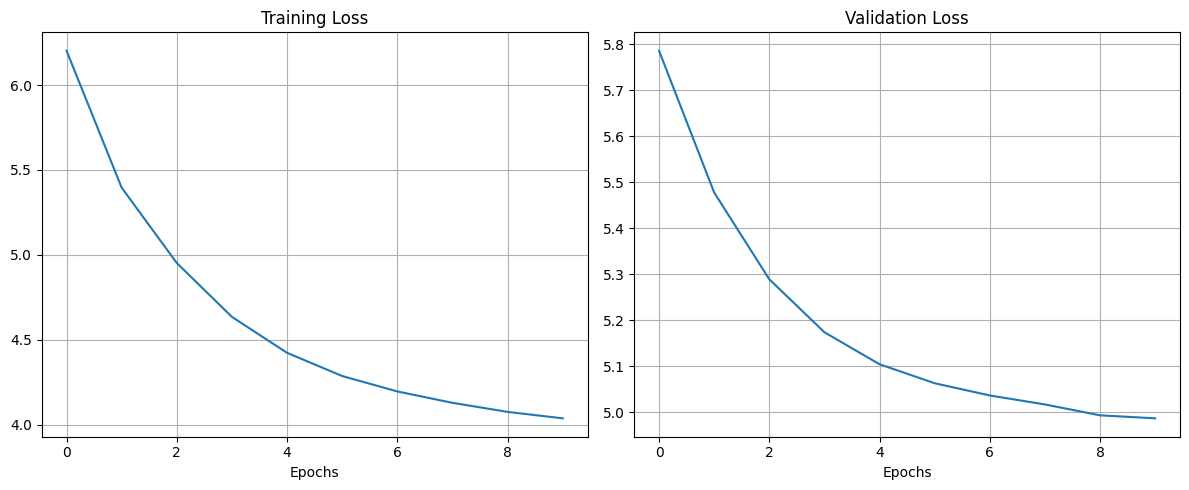

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(train_loss)
axes[0].set_xlabel("Epochs")
axes[0].set_title("Training Loss")
axes[0].grid(True)

axes[1].plot(val_loss)
axes[1].set_xlabel("Epochs")
axes[1].set_title("Validation Loss")
axes[1].grid(True)

plt.tight_layout()
plt.show()

Perplexity

In [ ]:
train_ppl = [math.exp(loss) for loss in train_loss]
val_ppl = [math.exp(loss) for loss in val_loss]

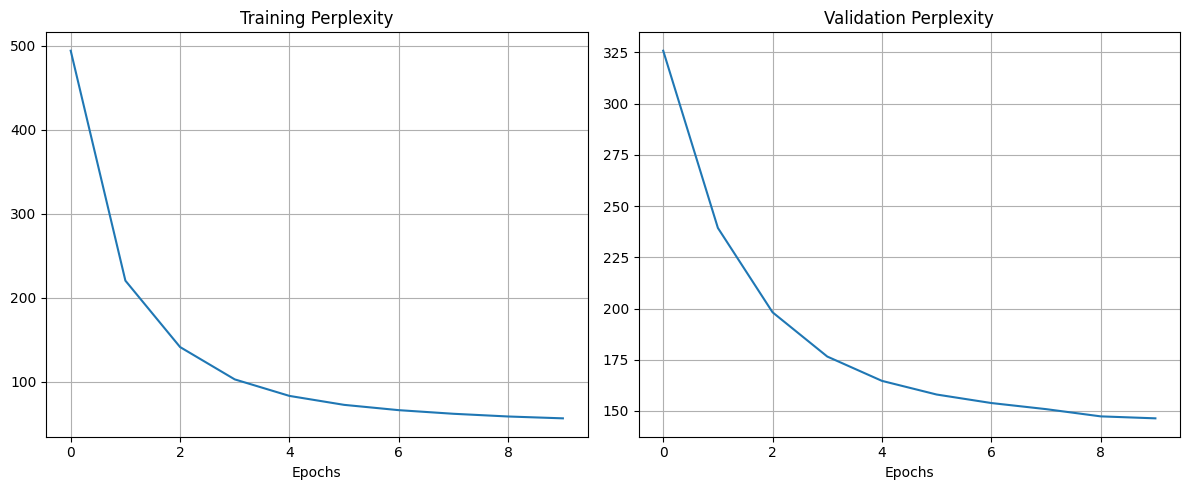

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(train_ppl)
axes[0].set_xlabel("Epochs")
axes[0].set_title("Training Perplexity")
axes[0].grid(True)

axes[1].plot(val_ppl)
axes[1].set_xlabel("Epochs")
axes[1].set_title("Validation Perplexity")
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
print(f'Final perplexity: {val_ppl[-1]:.2f}')

---
### Testing the model
#### Text generation

In [ ]:
def text_generation(_text:str, _model=model, _vocab=vocab, _max_lenght:int=10):

  # Get only the words from the input text
  _text = _text.strip().lower().split()

  _model.eval()

  vocab_2 = {idx: word for word, idx in _vocab.items()}

  # Tokenizer
  context = [_vocab.get(word, 0) for word in _text]

  # ensure 5-word context
  context = context[-5:]
  if len(context) < 5:
    # add 0 if the context has fewer than 5 words
    context = [0] * (5 - len(context)) + context

  generated = context.copy()

  for _ in range(_max_lenght):

    # move to tensor
    context_tensor = torch.tensor([context], dtype=torch.long).to(device)

    with torch.no_grad():
      logits = _model(context_tensor)

    # select the most likely word
    token = torch.argmax(logits.squeeze(), dim=-1).item()
    # if it's a word not present in the vocabulary
    if token == 0:
      continue

    generated.append(token)
    context = generated[-5:]

  return ' '.join([vocab_2[token] for token in generated])

In [ ]:
print(text_generation('a vida não é um'))

a vida não é um drama que eu não posso estar comigo não te peço
